**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


## Logistic regressor

### Data Preparation

In [2]:
from collections import Counter
from collections import defaultdict

In [36]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,...,4,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0
1,2,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0
2,2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,...,1,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0
3,3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,...,1,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0
4,1,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,...,1,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0


In [37]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (8460, 83)
Shape y: (8460,)


### Data Partitioning

In [38]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [40]:
from sklearn.preprocessing import StandardScaler

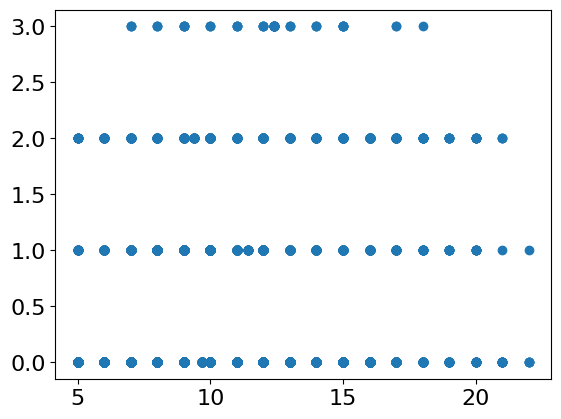

In [41]:
plt.scatter(X_train.T[1], y_train)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [42]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

#### Smote

In [43]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {0.0: 4084, 1.0: 4084, 2.0: 4084, 3.0: 4084}


In [44]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(16336, 27)

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [46]:
clf = LogisticRegression(random_state=0)

clf.fit(X_train_scaled, y_train_resampled)
y_pred = clf.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.5201
F1-score (par classe) : [0.69212886 0.33295063 0.34965035 0.03340292]

Classification Report complet :
              precision    recall  f1-score   support

         0.0       0.83      0.60      0.69      1749
         1.0       0.37      0.30      0.33       482
         2.0       0.29      0.45      0.35       280
         3.0       0.02      0.30      0.03        27

    accuracy                           0.52      2538
   macro avg       0.38      0.41      0.35      2538
weighted avg       0.67      0.52      0.58      2538



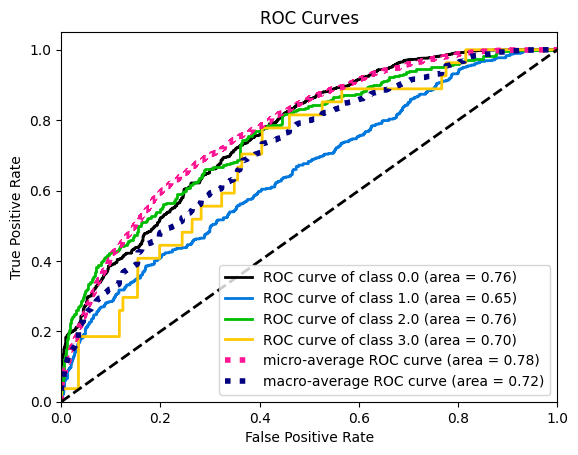

In [47]:
y_score = clf.predict_proba(X_test_scaled)
plot_roc(y_test, y_score)
plt.show()

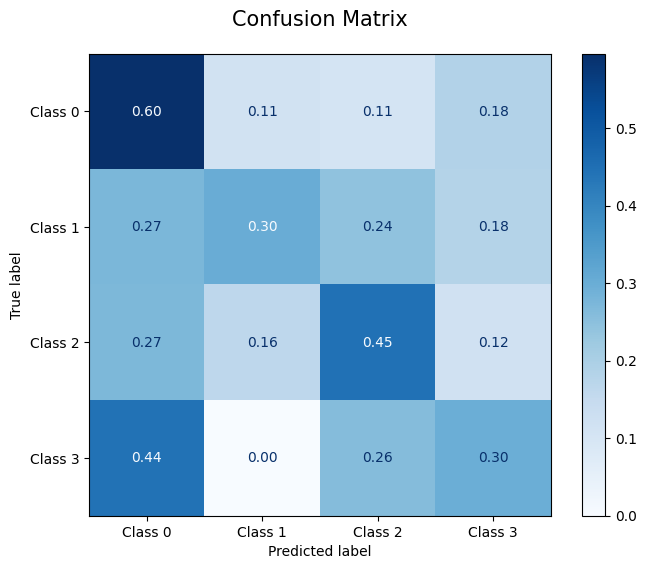

In [48]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

#### Random under sampling

In [50]:
# RandomUnderSampler sur le train set uniquement 
ros = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print(f"Before RUS : {X_train_scaled.shape[0]} samples")
print(f"After RUS : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after RUS : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before RUS : 16336 samples
After RUS : 244 samples
Distribution of classes after RUS : {0.0: 61, 1.0: 61, 2.0: 61, 3.0: 61}


In [51]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(244, 33)

In [52]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [53]:
clf = LogisticRegression(random_state=0)

clf.fit(X_train_scaled, y_train_resampled)
y_pred = clf.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.4555
F1-score (par classe) : [0.63216395 0.26826827 0.27430093 0.04026846]

Classification Report complet :
              precision    recall  f1-score   support

         0.0       0.81      0.52      0.63      1749
         1.0       0.26      0.28      0.27       482
         2.0       0.22      0.37      0.27       280
         3.0       0.02      0.33      0.04        27

    accuracy                           0.46      2538
   macro avg       0.33      0.37      0.30      2538
weighted avg       0.63      0.46      0.52      2538



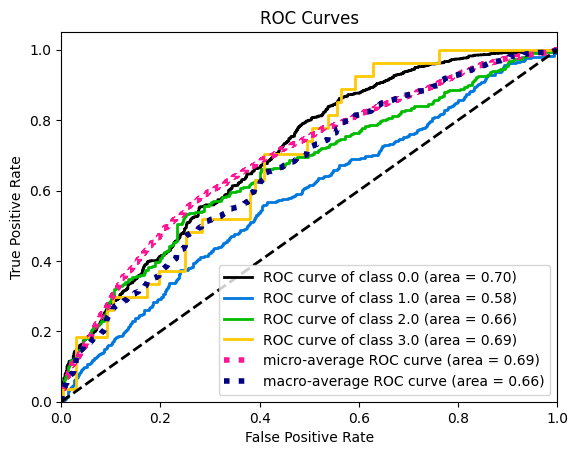

In [54]:
y_score = clf.predict_proba(X_test_scaled)
plot_roc(y_test, y_score)
plt.show()

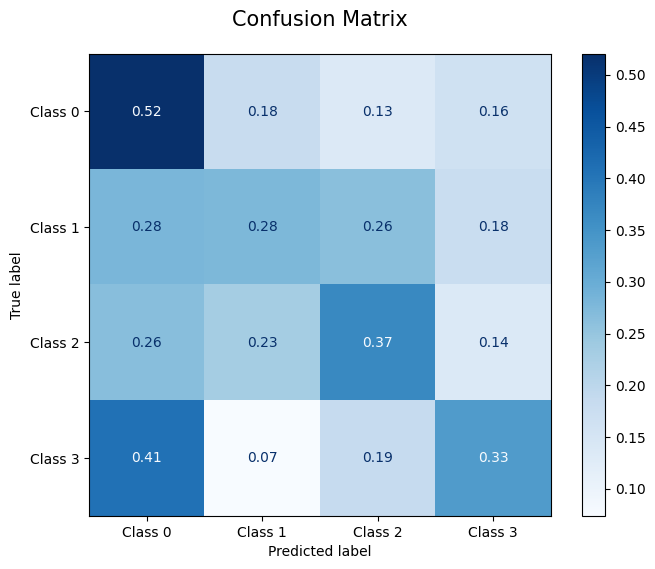

In [55]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

It proves that while SMOTE forced the model to pay attention to classes 2 and 3, Logistic Regression is too rigid (linear) to handle the complexity of this specific dataset.

It clearly demonstrates that features cannot separate the classes using simple linear rules.

### New target variable data preparation 

**Basic_Demos-Sex**

In [56]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,...,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0,2.0
1,2,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0,0.0
2,2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,...,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0,0.0
3,3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,...,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0,1.0
4,1,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,...,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0,0.0


In [57]:
df_log_reg = df.copy()

In [58]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [59]:
X = df.values
y = np.array(df_log_reg['Basic_Demos-Sex'])

In [60]:
ctr = Counter(y)
ctr

Counter({0: 5056, 1: 3404})

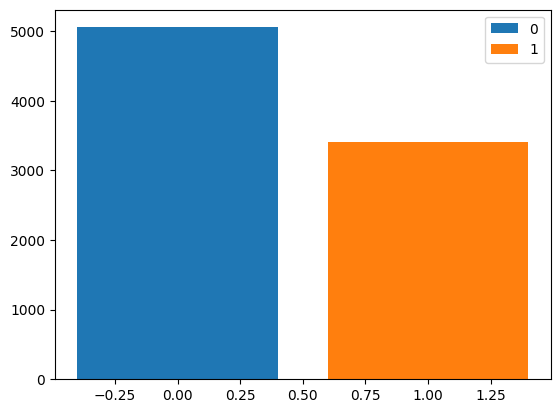

In [61]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange'])
plt.legend()
plt.show()

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

#### Smote

In [64]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 7080 samples
Distribution of classes after SMOTE : {0: 3540, 1: 3540}


In [65]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(7080, 26)

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [67]:
clf = LogisticRegression(random_state=0)

clf.fit(X_train_scaled, y_train_resampled)
y_pred = clf.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.6261
F1-score (par classe) : [0.65973467 0.58504591]

Classification Report complet :
              precision    recall  f1-score   support

           0       0.72      0.61      0.66      1516
           1       0.53      0.65      0.59      1022

    accuracy                           0.63      2538
   macro avg       0.63      0.63      0.62      2538
weighted avg       0.64      0.63      0.63      2538



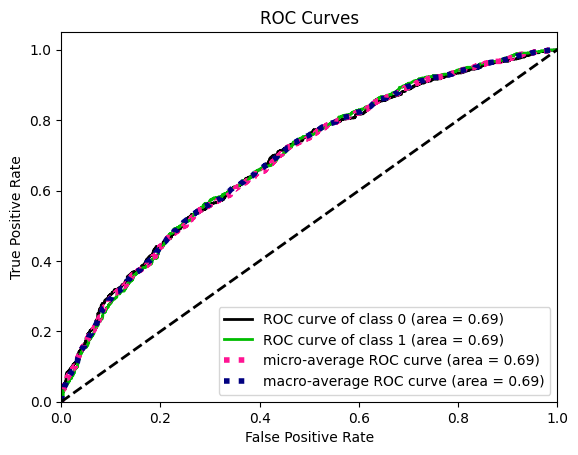

In [68]:
y_score = clf.predict_proba(X_test_scaled)
plot_roc(y_test, y_score)
plt.show()

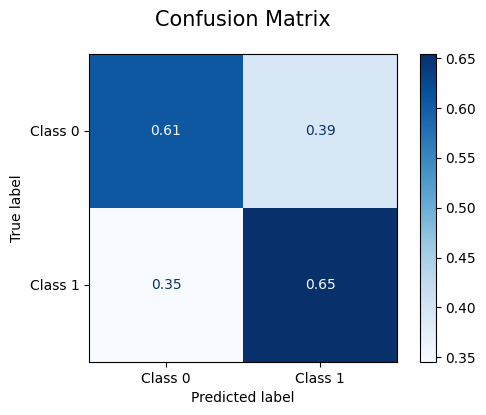

In [71]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

#### Random under sampling

In [72]:
# RandomUnderSampler sur le train set uniquement 
ros = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print(f"Before RUS : {X_train_scaled.shape[0]} samples")
print(f"After RUS : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after RUS : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before RUS : 7080 samples
After RUS : 4764 samples
Distribution of classes after RUS : {0: 2382, 1: 2382}


In [73]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(4764, 23)

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

In [75]:
clf = LogisticRegression(random_state=0)

clf.fit(X_train_scaled, y_train_resampled)
y_pred = clf.predict(X_test_scaled)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.6667
F1-score (par classe) : [0.70502092 0.61684783]

Classification Report complet :
              precision    recall  f1-score   support

           0       0.75      0.67      0.71      1516
           1       0.57      0.67      0.62      1022

    accuracy                           0.67      2538
   macro avg       0.66      0.67      0.66      2538
weighted avg       0.68      0.67      0.67      2538



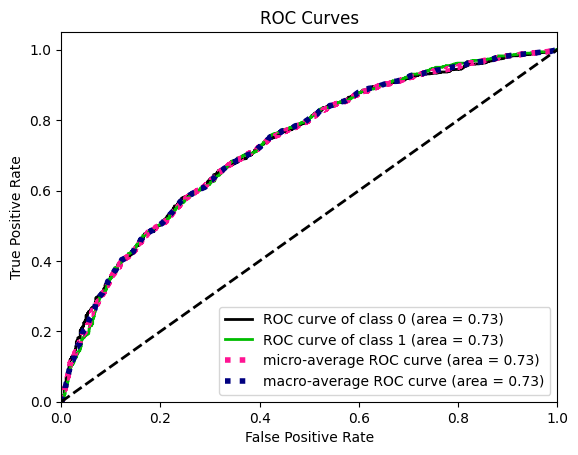

In [76]:
y_score = clf.predict_proba(X_test_scaled)
plot_roc(y_test, y_score)
plt.show()

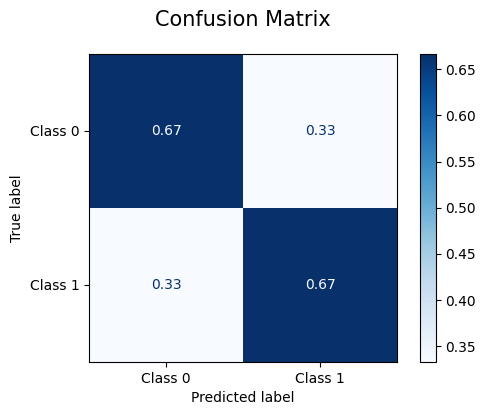

In [78]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()